In [2]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix
import itertools
import numpy as np
import os

In [3]:
# CONFIGURATION

dataset_old = "trainable_dataset"   
train_dir = os.path.join(dataset_old, "train")
val_dir   = os.path.join(dataset_old, "val")
test_dir  = os.path.join(dataset_old, "test")
image_size = 224
batch_size = 16
num_epochs = 50
learning_rate = 0.0003
weight_decay = 0.05
save_dir = "./vit_results_updated"
os.makedirs(save_dir, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


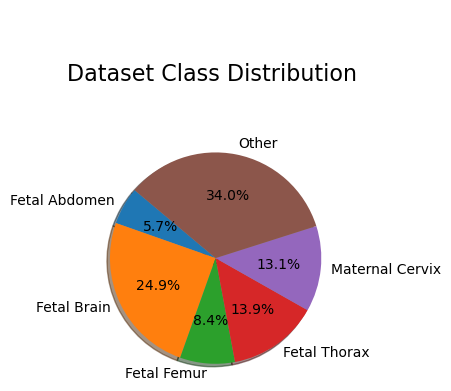

Fetal Abdomen: 568 images
Fetal Brain: 2473 images
Fetal Femur: 832 images
Fetal Thorax: 1374 images
Maternal Cervix: 1300 images
Other: 3370 images


In [4]:
data_dir = train_dir

# Count number of images in each class folder
class_counts = {}
for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)
    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

# Extract labels and counts
labels = list(class_counts.keys())
sizes = list(class_counts.values())

# Plot pie chart
plt.figure(figsize=(3, 3))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    shadow=True
)
plt.title("\n\nDataset Class Distribution \n\n", fontsize=16)
plt.axis('equal')  # Equal aspect ratio ensures pie is drawn as a circle.
plt.show()

# Print details
for label, count in class_counts.items():
    print(f"{label}: {count} images")

In [4]:
# DATA PREPROCESSING
#mean = [0.1743, 0.1743, 0.1744]
#std = [0.1701, 0.1701, 0.1702]
train_tfms = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    #transforms.Normalize(mean=mean,std=std),
])

val_tfms = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    #transforms.Normalize(mean=mean,std=std),
])

test_tfms = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    #transforms.Normalize(mean=mean,std=std),
])

In [5]:
train_ds = datasets.ImageFolder(train_dir, transform=train_tfms)
val_ds   = datasets.ImageFolder(val_dir, transform=val_tfms)
test_ds  = datasets.ImageFolder(test_dir, transform=val_tfms)

In [6]:
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=4)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=4)

class_names = train_ds.classes
num_classes = len(train_ds.classes)
print(f"Classes: {class_names}")

Classes: ['Fetal Abdomen', 'Fetal Brain', 'Fetal Femur', 'Fetal Thorax', 'Maternal Cervix', 'Other']


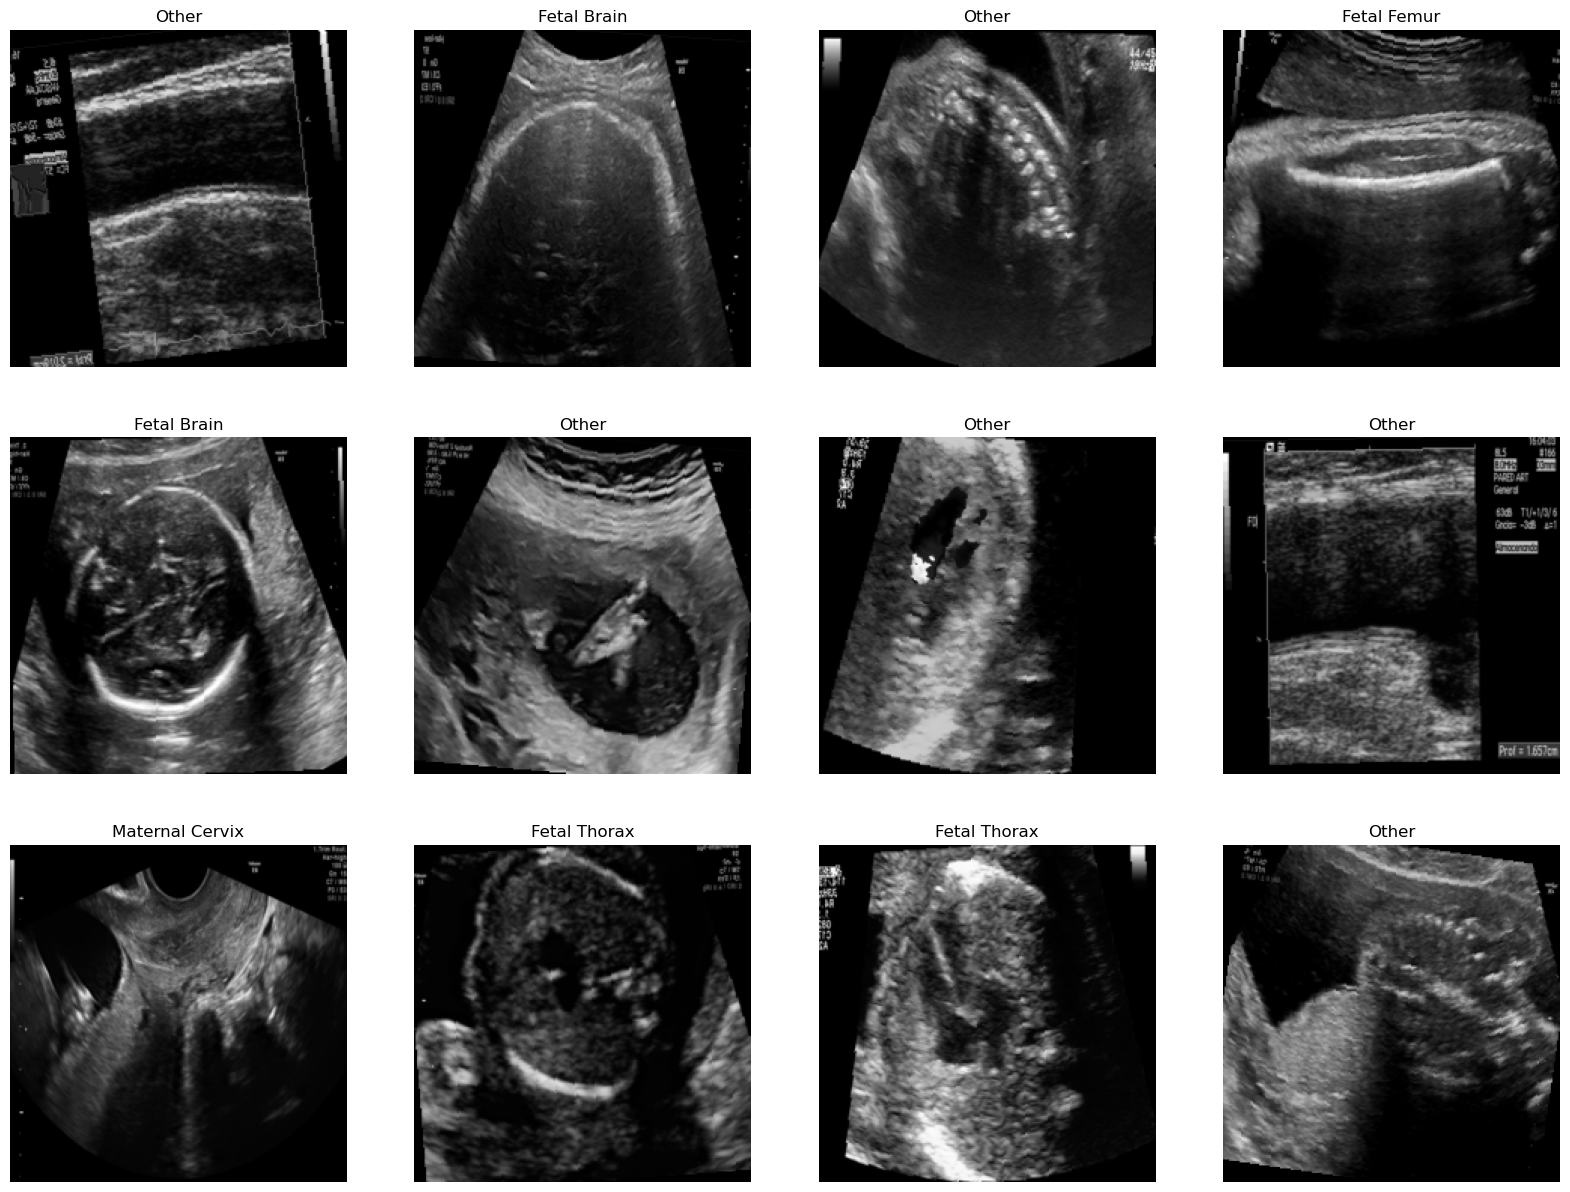

In [7]:
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Create a figure
plt.figure(figsize=(20, 15))

for i in range(12):
    ax = plt.subplot(3, 4, i + 1)
    
    # Move tensor to CPU and convert to NumPy
    img = images[i].cpu().numpy()
    
    # Transpose image from (C, H, W) to (H, W, C)
    img = img.transpose((1, 2, 0)) 
    plt.imshow(img)
    plt.title(train_ds.classes[labels[i]])
    plt.axis("off")
plt.show()

In [8]:
# VISION TRANSFORMER MODEL

class PatchEmbedding(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=768):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_chans, embed_dim,
                              kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)          # (B, embed_dim, H/patch, W/patch)
        x = x.flatten(2).transpose(1, 2)  # (B, num_patches, embed_dim)
        return x

In [9]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, int(embed_dim * mlp_ratio)),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(int(embed_dim * mlp_ratio), embed_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x

In [10]:
class VisionTransformer(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3,
                 num_classes=num_classes, embed_dim=256, depth=6, num_heads=8, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_chans, embed_dim)
        num_patches = self.patch_embed.num_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.pos_drop = nn.Dropout(dropout)

        self.blocks = nn.Sequential(
            *[TransformerEncoderBlock(embed_dim, num_heads, dropout=dropout) for _ in range(depth)]
        )

        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embed
        x = self.pos_drop(x)

        x = self.blocks(x)
        x = self.norm(x)
        cls_output = x[:, 0]
        return self.head(cls_output)

In [15]:
# INITIALIZE MODEL, LOSS, OPTIMIZER

model = VisionTransformer(img_size=image_size, num_classes=num_classes).to(device)
class_counts = torch.tensor([568, 2473, 832, 1374, 1300, 3370], dtype=torch.float, device=device)
weights = 1.0 / class_counts
weights = weights / weights.sum()

criterion = nn.CrossEntropyLoss(weight=weights.to(device))
model = model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

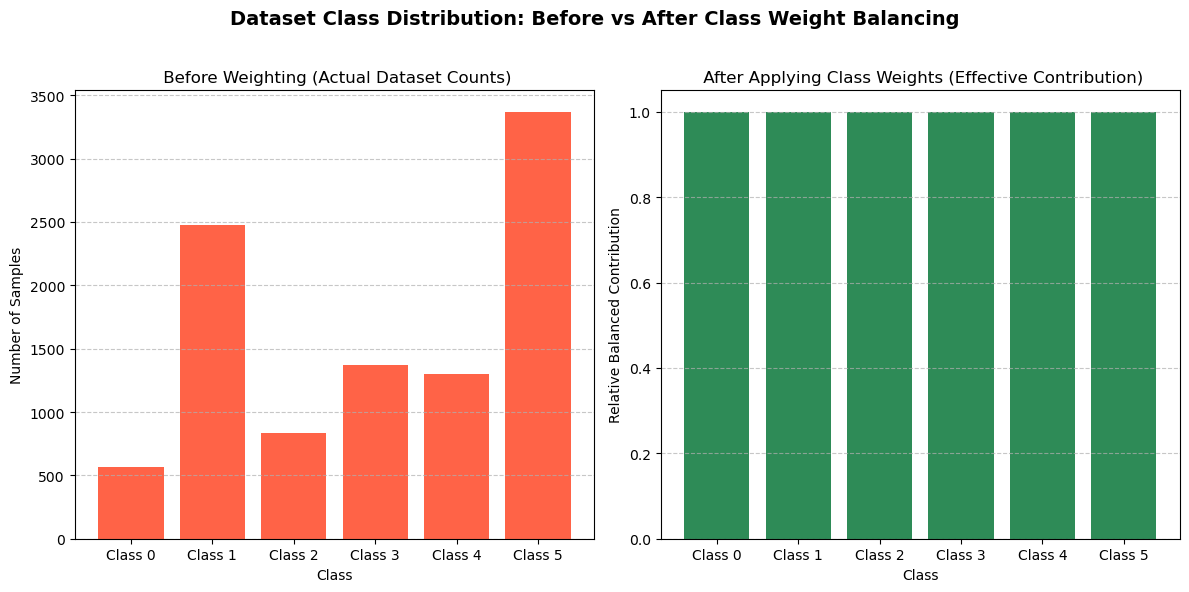

In [16]:
class_counts = np.array([568, 2473, 832, 1374, 1300, 3370])
classes = np.arange(len(class_counts))

# Compute class weights (inverse of counts)
weights = 1.0 / class_counts
weights = weights / weights.sum()  # normalized

# Compute "effective" balanced representation
# Multiply each class count by its corresponding weight
balanced_effect = class_counts * weights
balanced_effect = balanced_effect / balanced_effect.max()  # normalize for visualization

# Plot setup
plt.figure(figsize=(12,6))

# --- Before weighting ---
plt.subplot(1, 2, 1)
plt.bar(classes, class_counts, color='tomato')
plt.xticks(classes, [f'Class {i}' for i in classes])
plt.title(' Before Weighting (Actual Dataset Counts)')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# --- After weighting ---
plt.subplot(1, 2, 2)
plt.bar(classes, balanced_effect, color='seagreen')
plt.xticks(classes, [f'Class {i}' for i in classes])
plt.title(' After Applying Class Weights (Effective Contribution)')
plt.xlabel('Class')
plt.ylabel('Relative Balanced Contribution')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle("Dataset Class Distribution: Before vs After Class Weight Balancing", fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [17]:
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_acc = 0.0
best_model_path = os.path.join(save_dir, "best_vit.pth")

def evaluate(loader):
    model.eval()
    loss_sum, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss_sum += loss.item() * imgs.size(0)
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += imgs.size(0)
    return loss_sum/total, correct/total

for epoch in range(num_epochs):
    model.train()
    total_loss, total_correct, total = 0, 0, 0
    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}]")

    for imgs, labels in loop:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        preds = outputs.argmax(1)
        total_loss += loss.item() * imgs.size(0)
        total_correct += (preds == labels).sum().item()
        total += imgs.size(0)
        loop.set_postfix(loss=total_loss/total, acc=total_correct/total)

    train_loss, train_acc = total_loss/total, total_correct/total
    val_loss, val_acc = evaluate(val_loader)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")
    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f" Saved best model (val_acc={best_acc:.4f})")


Epoch [1/100]: 100%|███████████████████████████████████████████| 620/620 [02:18<00:00,  4.47it/s, acc=0.443, loss=1.41]


Epoch 1: Train Acc=0.4430, Val Acc=0.5073
Epoch 1: Train Loss=1.4091, Val Loss=1.2174
 Saved best model (val_acc=0.5073)


Epoch [2/100]: 100%|███████████████████████████████████████████| 620/620 [02:51<00:00,  3.62it/s, acc=0.556, loss=1.16]


Epoch 2: Train Acc=0.5559, Val Acc=0.6089
Epoch 2: Train Loss=1.1618, Val Loss=1.0907
 Saved best model (val_acc=0.6089)


Epoch [3/100]: 100%|█████████████████████████████████████████████| 620/620 [01:08<00:00,  9.01it/s, acc=0.57, loss=1.1]


...

Epoch 98: Train Acc=0.9408, Val Acc=0.9000
Epoch 98: Train Loss=0.1234, Val Loss=0.3518


Epoch [99/100]: 100%|██████████████████████████████████████████| 620/620 [02:15<00:00,  4.56it/s, acc=0.94, loss=0.121]


Epoch 99: Train Acc=0.9400, Val Acc=0.8992
Epoch 99: Train Loss=0.1205, Val Loss=0.3536


Epoch [100/100]: 100%|████████████████████████████████████████| 620/620 [02:12<00:00,  4.68it/s, acc=0.942, loss=0.121]


Epoch 100: Train Acc=0.9424, Val Acc=0.8992
Epoch 100: Train Loss=0.1212, Val Loss=0.3535


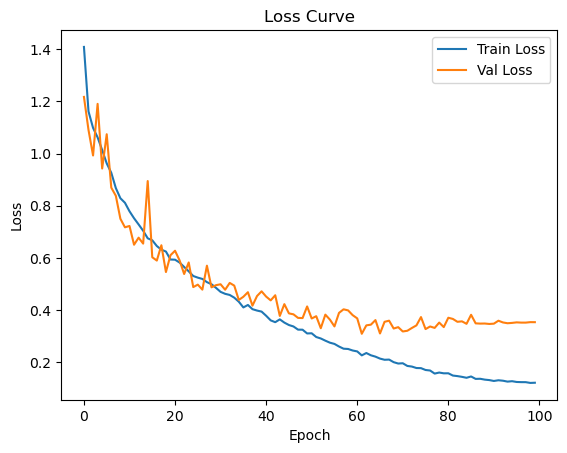

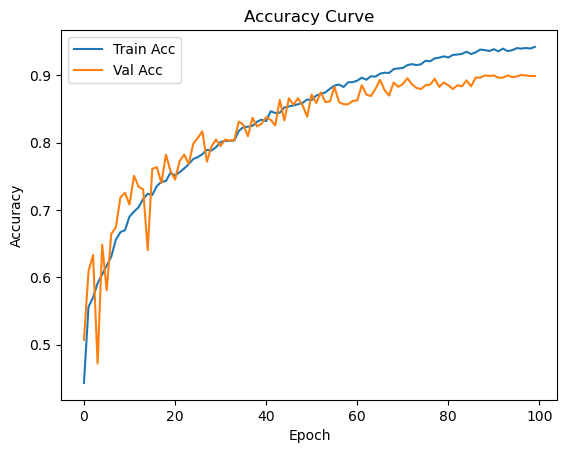

'\nplt.savefig(os.path.join(save_dir, "acc_curve.png"))\nplt.close()\nprint("Saved training curves to", save_dir)\n'

In [18]:

# PLOT TRAINING CURVES

plt.figure()
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()
"""
plt.savefig(os.path.join(save_dir, "loss_curve.png"))
plt.close()
"""
plt.figure()
plt.plot(history["train_acc"], label="Train Acc")
plt.plot(history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.show()
"""
plt.savefig(os.path.join(save_dir, "acc_curve.png"))
plt.close()
print("Saved training curves to", save_dir)
"""

In [19]:
classes=test_ds.classes
print(classes)

['Fetal Abdomen', 'Fetal Brain', 'Fetal Femur', 'Fetal Thorax', 'Maternal Cervix', 'Other']


In [20]:
model.load_state_dict(torch.load(best_model_path))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Testing"):
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


report = classification_report(all_labels, all_preds, target_names=train_ds.classes, digits=4)
print(report)

Testing: 100%|█████████████████████████████████████████████████████████████████████████| 78/78 [00:22<00:00,  3.44it/s]

                 precision    recall  f1-score   support

  Fetal Abdomen     0.6087    0.7778    0.6829        72
    Fetal Brain     0.9625    0.9904    0.9762       311
    Fetal Femur     0.7462    0.9327    0.8291       104
   Fetal Thorax     0.8333    0.9302    0.8791       172
Maternal Cervix     0.9815    0.9876    0.9845       161
          Other     0.9509    0.7796    0.8568       422

       accuracy                         0.8929      1242
      macro avg     0.8472    0.8997    0.8681      1242
   weighted avg     0.9045    0.8929    0.8939      1242



In [21]:
with open(os.path.join(save_dir, "classification_report.txt"), "w") as f:
    f.write(report)


In [22]:
cm = confusion_matrix(all_labels, all_preds)
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion Matrix', path=None):
    if normalize:
        cm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-12)
    plt.figure(figsize=(8,8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=90)
    plt.yticks(tick_marks, classes)
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 ha="center", color="white" if cm[i, j] > thresh else "black")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()
    """
    plt.tight_layout()
    if path:
        plt.savefig(path)
    plt.close()
    """

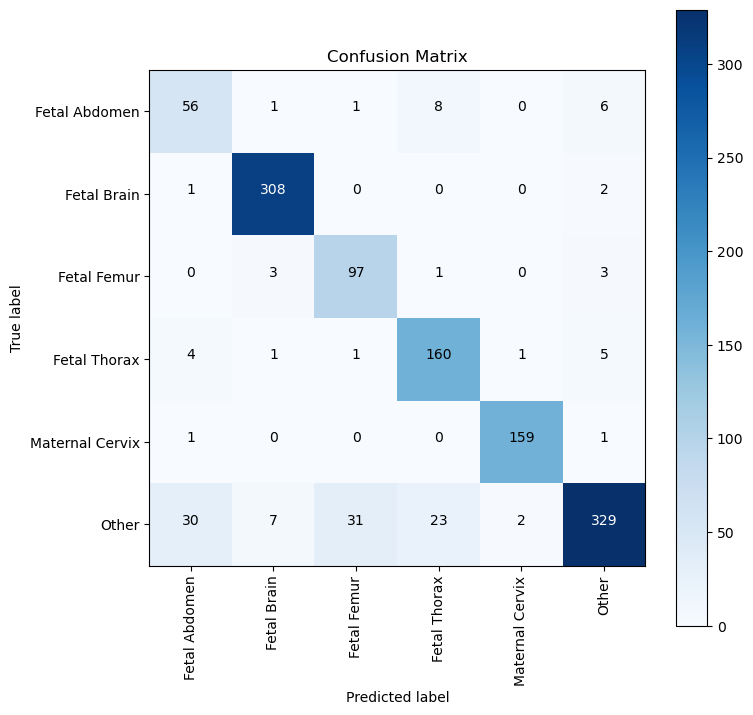

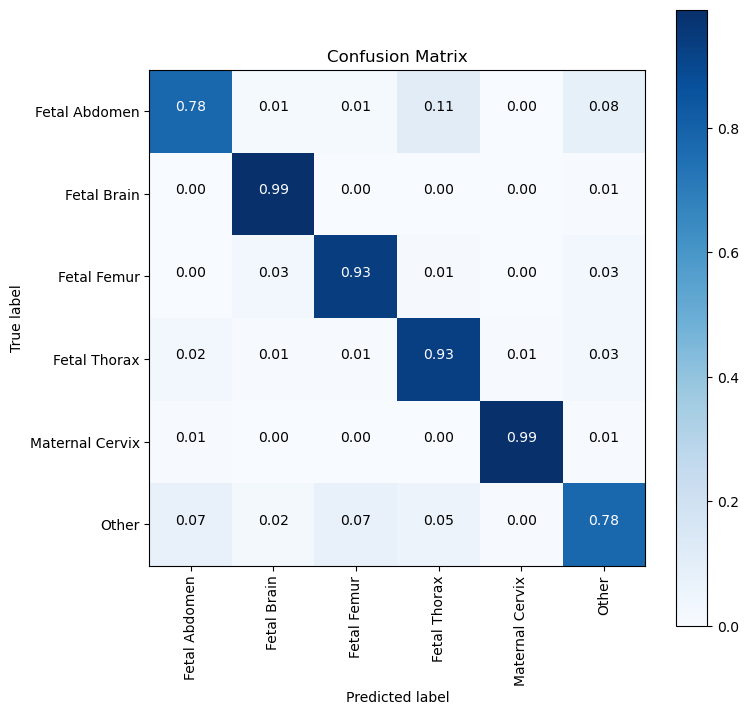

In [23]:
plot_confusion_matrix(cm, train_ds.classes, normalize=False,
                      path=os.path.join(save_dir, "confusion_matrix.png"))
plot_confusion_matrix(cm, train_ds.classes, normalize=True,
                      path=os.path.join(save_dir, "confusion_matrix_normalized.png"))

In [24]:
from PIL import Image

In [25]:
image_path = "trainable_dataset/test/Fetal Thorax/Patient00730_Plane6_6_of_6.png"  # path to your test image
model.to(device)
model.eval()
image = Image.open(image_path).convert('RGB')
input_tensor = test_tfms(image).unsqueeze(0).to(device)

In [26]:
with torch.no_grad():
    outputs = model(input_tensor)
    probabilities = F.softmax(outputs, dim=1)
    confidence, predicted_class = torch.max(probabilities, 1)
    confidence = confidence.item() * 100
    predicted_class = predicted_class.item()
    
class_names = ['Fetal Abdomen', 'Fetal Brain', 'Fetal Femur', 'Fetal Thorax', 'Maternal Cervix', 'Other']

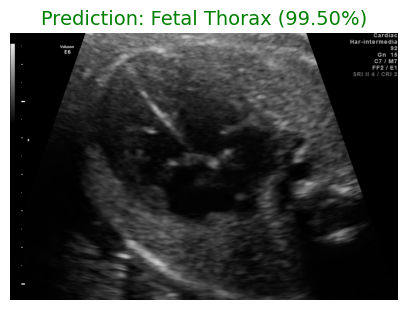

 Predicted Class: Fetal Thorax
 Confidence: 99.50%


In [28]:
plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.axis('off')
plt.title(f"Prediction: {class_names[predicted_class]} ({confidence:.2f}%)", fontsize=14, color='green')
plt.show()
print(f" Predicted Class: {class_names[predicted_class]}")
print(f" Confidence: {confidence:.2f}%")